### Load Data

conda activate preprocess_data

In [15]:
import glob
import sys
import os
import re
import numpy as np
import tifffile as tiff
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import random
from send2trash import send2trash

folder_path = r"C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\virtual_staining_processing_inference_functions"
sys.path.append(folder_path)
from processing_functions import *


# Crop the Data

In [16]:
import os
import numpy as np
import tifffile
from pathlib import Path

def crop_and_save_tifs(input_dir, output_dir, crop_ratio_h=0.8, crop_ratio_w=0.8):
    """
    Crop the central region of each .tif image using separate height and width crop ratios.

    Args:
        input_dir (str or Path): Folder containing .tif images.
        output_dir (str or Path): Folder to save cropped images.
        crop_ratio_h (float): Fraction of image height to keep (0 < crop_ratio_h <= 1).
        crop_ratio_w (float): Fraction of image width to keep (0 < crop_ratio_w <= 1).
    """
    assert 0 < crop_ratio_h <= 1, "crop_ratio_h must be in (0, 1]"
    assert 0 < crop_ratio_w <= 1, "crop_ratio_w must be in (0, 1]"

    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for tif_file in input_dir.glob('*.tif'):
        img = tifffile.imread(tif_file)
        dtype = img.dtype

        H, W = img.shape[:2]
        h_margin = int(H * (1 - crop_ratio_h) / 2)
        w_margin = int(W * (1 - crop_ratio_w) / 2)

        cropped = img[h_margin:H - h_margin, w_margin:W - w_margin]
        save_path = output_dir / tif_file.name
        tifffile.imwrite(save_path, cropped.astype(dtype))

        print(f"Cropped and saved: {save_path}")

# Example usage:
#crop_and_save_tifs("data/input_tifs", "data/cropped_tifs", crop_ratio_h=0.8, crop_ratio_w=0.7)

import cv2
def preprocess_training_flatfield_contrast_enhance_data(output_path, stack_path, save_folder_name = "preprocessed"):
    imgs = glob.glob(stack_path + r'\*.tif')
    print(f"Found {len(imgs)} image for preprocessing.")
    save_path = os.path.join(output_path, save_folder_name)
    os.makedirs(save_path, exist_ok=True)
    clahe_clipLimit=2.0
    clahe_tileGridSize=8
    clahe = cv2.createCLAHE(clipLimit=clahe_clipLimit, tileGridSize=(clahe_tileGridSize, clahe_tileGridSize))

    for img_name in imgs:
        base_name = os.path.basename(img_name)
        print(f"Processing stack: {base_name}")
        img = tiff.imread(img_name)
        img = np.array(img, dtype=img.dtype)
        print(f"Original stack shape: {img.shape}, dtype: {img.dtype}")

        # Flatfield Correction for BIT images
        img = flatfield_correct(img, sigma=50)

        # Cast image to uint16 after normalization for CLAHE
        img = cv2.normalize(img, None, 0, 65535, cv2.NORM_MINMAX).astype(np.uint16)

        if 'MUSE' in sample_name:
            # Apply CLAHE for contrast enhancement
            img = clahe.apply(img)

        # Normalize to 8-bit
        img = normalize_16bit_to_8bit(img)


        if 'BIT' in sample_name:
            # Replace saturated and dark pixels with median value
            img_median = np.median(img)
            saturated_mask = (img == 255)
            dark_mask = (img == 0)
            img[saturated_mask | dark_mask] = img_median


        # Median Filter to reduce granularity
        medfilter_kernel_size = 3
        img = cv2.medianBlur(img, medfilter_kernel_size)

        # Save the enhanced stack
        img_save_path = os.path.join(save_path, base_name)
        tiff.imwrite(img_save_path, img)
        print(f"Original stack shape: {img.shape}, dtype: {img.dtype}")

  
import numpy as np
import cv2  # Optional, for image writing or visualization

def normalize_16bit_to_8bit(image_16bit: np.ndarray, percentiles = (1, 99.9)) -> np.ndarray:
    """
    Normalize a 16-bit image to 8-bit using the 1st and 99th percentiles.

    Args:
        image_16bit (np.ndarray): Input 16-bit image (dtype=np.uint16)

    Returns:
        np.ndarray: Output 8-bit image (dtype=np.uint8)
    """
    assert image_16bit.dtype == np.uint16, "Input must be a 16-bit image"

    # Compute 1st and 99th percentiles
    p1 = np.percentile(image_16bit, percentiles[0])
    p99 = np.percentile(image_16bit, percentiles[1])

    # Clip the image to [p1, p99] range
    clipped = np.clip(image_16bit, p1, p99)

    # Normalize to [0, 255]
    normalized = (clipped - p1) / (p99 - p1) * 255.0

    # Convert to uint8
    image_8bit = normalized.astype(np.uint8)

    return image_8bit

import os
import re
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

def extract_xy(filename):
    """Extract X and Y values from the filename."""
    match = re.search(r'X=(\d+)_Y=(\d+)', filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None

def group_images_by_xy(image_files):
    """Group image file paths by (X, Y) tuple."""
    grouped = {}
    for f in image_files:
        key = extract_xy(f)
        if key:
            grouped.setdefault(key, []).append(f)
    return grouped

def show_images_with_checkboxes(image_paths, input_dir):
    """Display images with checkboxes to select which to keep."""
    checkboxes = []
    output = widgets.Output()
    with output:
        fig, axes = plt.subplots(1, len(image_paths), figsize=(4 * len(image_paths), 4))
        if len(image_paths) == 1:
            axes = [axes]

        for ax, img_path in zip(axes, image_paths):
            img = Image.open(os.path.join(input_dir, img_path))
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            ax.set_title(os.path.basename(img_path), fontsize=10)

        plt.show()

    checkbox_widgets = []
    for path in image_paths:
        cb = widgets.Checkbox(value=True, description=os.path.basename(path))
        checkbox_widgets.append(cb)

    return checkbox_widgets, output

def interactive_selector(input_dir):
    input_dir = os.path.abspath(input_dir)
    image_files = [f for f in os.listdir(input_dir) if 'BIT' in f and f.endswith('.tif')]
    grouped = group_images_by_xy(image_files)
    keys = sorted(grouped.keys())

    key_idx = 0  # Start at first group
    status = widgets.Label(value="")

    def show_group(idx):
        nonlocal key_idx
        key_idx = idx
        key = keys[idx]
        image_paths = grouped[key]

        clear_output(wait=True)
        print(f"Group (X={key[0]}, Y={key[1]}) — {len(image_paths)} images")

        checkboxes, output = show_images_with_checkboxes(image_paths, input_dir)
        box = widgets.VBox(checkboxes)

        keep_button = widgets.Button(description="Keep Selected")
        skip_button = widgets.Button(description="Keep All")
        delete_all_button = widgets.Button(description="Delete All")

        button_box = widgets.HBox([keep_button, skip_button, delete_all_button])

        def on_keep_clicked(b):
            to_keep = [img for cb, img in zip(checkboxes, image_paths) if cb.value]
            to_delete = set(image_paths) - set(to_keep)
            for file in to_delete:
                os.remove(os.path.join(input_dir, file))
                print(f"🗑️ Deleted: {file}")
            for file in to_keep:
                print(f"✅ Kept: {file}")
            next_group()

        def on_skip_clicked(b):
            print("✅ Kept all images in this group.")
            next_group()

        def on_delete_all_clicked(b):
            for file in image_paths:
                os.remove(os.path.join(input_dir, file))
                print(f"🗑️ Deleted: {file}")
            next_group()

        def next_group():
            if key_idx + 1 < len(keys):
                show_group(key_idx + 1)
            else:
                print("🎉 Done reviewing all (X,Y) groups.")

        keep_button.on_click(on_keep_clicked)
        skip_button.on_click(on_skip_clicked)
        delete_all_button.on_click(on_delete_all_clicked)

        display(output, box, button_box, status)

    show_group(key_idx)


## Break up BIT and MUSE images into training patches. 

### Load Data

#### Process: 
    1. Crop images to reduce edge artifacts. 
    2. Flatfield correct with sigma = 50 
    3. Normalize and case image to uint16
    4. Median filter with size 3 kernel
    5. Normalize 16bit to 8bit with 1% and 99.9%, min and max, respectively. 
    6. Select good images to keep. 

In [17]:
root = 'C:\\Users\\durrlab-asong\\Desktop\\virtual_staining_training_data\\duodenum\\BIT\\20260203_cropped_duodenum_crypts\\'

sample_name = 'roi_4'
data_input = os.path.join(root, sample_name, 'BIT')
#data_output = os.path.join(data_input, 'cropped_tifs')

# crop images
#crop_and_save_tifs(data_input, data_output, crop_ratio_h=0.9, crop_ratio_w=0.8)

# preprocess them.
preprocess_training_flatfield_contrast_enhance_data(data_input, data_input, save_folder_name = "preprocessed_new")

# take good images. 
#interactive_selector(os.path.join(data_output, 'preprocessed'))  

Found 200 image for preprocessing.
Processing stack: crop_4_BIT_crypt_3_X=0_Y=0_Z=0_expTime=9ms.tif
Original stack shape: (1294, 1200), dtype: uint16
Original stack shape: (1294, 1200), dtype: uint8
Processing stack: crop_4_BIT_crypt_3_X=0_Y=0_Z=10_expTime=9ms.tif
Original stack shape: (1294, 1200), dtype: uint16
Original stack shape: (1294, 1200), dtype: uint8
Processing stack: crop_4_BIT_crypt_3_X=0_Y=0_Z=11_expTime=9ms.tif
Original stack shape: (1294, 1200), dtype: uint16
Original stack shape: (1294, 1200), dtype: uint8
Processing stack: crop_4_BIT_crypt_3_X=0_Y=0_Z=12_expTime=9ms.tif
Original stack shape: (1294, 1200), dtype: uint16
Original stack shape: (1294, 1200), dtype: uint8
Processing stack: crop_4_BIT_crypt_3_X=0_Y=0_Z=13_expTime=9ms.tif
Original stack shape: (1294, 1200), dtype: uint16
Original stack shape: (1294, 1200), dtype: uint8
Processing stack: crop_4_BIT_crypt_3_X=0_Y=0_Z=14_expTime=9ms.tif
Original stack shape: (1294, 1200), dtype: uint16
Original stack shape: (12

In [18]:


def compute_optimal_stride(img_shape, patch_size, overlap_percent=0.10):
    """
    Computes the optimal stride (x, y) for given image shape and patch size
    to achieve the desired overlap and ensure full coverage.

    Args:
        img_shape (tuple): (height, width) of the image
        patch_size (int): size of the square patch
        overlap_percent (float): desired fractional overlap (e.g., 0.1 for 10%)

    Returns:
        tuple: (x_stride, y_stride)
    """
    import math

    h, w = img_shape

    # Initial stride from overlap percentage
    stride = int(patch_size * (1 - overlap_percent))
    stride = max(1, stride)

    # Compute number of patches along height and width (round up to ensure coverage)
    n_patches_y = math.ceil((h - patch_size) / stride) + 1
    n_patches_x = math.ceil((w - patch_size) / stride) + 1

    # Recompute stride so that last patch ends exactly at (h - patch_size) and (w - patch_size)
    if n_patches_y > 1:
        y_stride = (h - patch_size) // (n_patches_y - 1)
    else:
        y_stride = 0

    if n_patches_x > 1:
        x_stride = (w - patch_size) // (n_patches_x - 1)
    else:
        x_stride = 0

    return y_stride, x_stride



def flatfield_correct(image, sigma=50):
    """
    Perform flat-field correction on an image using Gaussian smoothing.
    
    Parameters:
        image: np.ndarray
            Input image (grayscale or multi-channel).
        sigma: float
            Gaussian blur sigma for estimating the background illumination.
    
    Returns:
        corrected: np.ndarray
            Flat-field corrected image as float32.
    """
    image = np.ascontiguousarray(image, dtype=np.float32)
    #image = np.asarray(image).astype(np.float32) # ensure image is a numpy array. 
    blurred = cv2.GaussianBlur(image, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
    corrected = image / (blurred + 1e-8)  # avoid division by zero
    return corrected

import numpy as np
import re

def normalize_to_uint8_percentile(img: np.ndarray, percentile = 100) -> np.ndarray:
    """
    Normalize a grayscale image using min-max normalization with clipping at the 95th percentile,
    then scale to [0, 255] and convert to uint8.

    Parameters:
        img (np.ndarray): Input grayscale image (2D or 3D if single-channel).

    Returns:
        np.ndarray: Normalized image as uint8 in [0, 255].
    """
    img = img.astype(np.float32)
    p_min = np.min(img)
    p_max = np.percentile(img, percentile)

    img_clipped = np.clip(img, p_min, p_max)
    img_norm = (img_clipped - p_min) / (p_max - p_min + 1e-8)  # avoid divide-by-zero
    img_uint8 = (img_norm * 255).astype(np.uint8)

    return img_uint8

def break_image_into_training_patches_new(base_name, img, output_folder, patch_size,
                                      x_step_size, y_step_size):
    """
    Break an image into patches and save metadata for reconstruction. Supports custom x and y step sizes.

    Parameters:
        img_type (str): Identifier for the image type
        img_num (int or str): Image number
        img_path (str): Path to the input image
        img (PIL.Image or np.ndarray): Loaded image
        output_folder (str): Folder to save patches and metadata
        patch_size (int): Size of each square patch (patch is patch_size x patch_size)
        x_step_size (int): Horizontal stride between patches
        y_step_size (int): Vertical stride between patches
        n_random (int): Number of additional random patches to extract
        seed (int): Random seed for reproducibility
    """
    os.makedirs(output_folder, exist_ok=True)
    

    img_np = np.array(img)
    if img_np.ndim == 3 and img_np.shape[2] > 1:
        raise ValueError("This function currently only supports single-channel (grayscale) images.")
    
    h, w = img_np.shape[:2]
    patch_counter = 1
    patch_info_list = []
    taken_coords = set()
    name_no_ext = os.path.splitext(os.path.basename(base_name))[0]
    match = re.search(r"Z=(\d+)", name_no_ext)
    if not match:
        raise ValueError(f"Could not parse Z value from filename: {name_no_ext}")
    img_num = int(match.group(1))
    # Remove Z=(\d+) from name_no_ext
    name_no_ext = re.sub(r"_Z=\d+", "", name_no_ext)
    name_no_ext = re.sub(r"_expTime=\d+ms", "", name_no_ext)

    # Step 1: Regular grid patches
    for y in range(0, h - patch_size + 1, y_step_size):
        for x in range(0, w - patch_size + 1, x_step_size):
            patch = img_np[y:y+patch_size, x:x+patch_size]
            patch_name = f"{name_no_ext}_img={img_num}_P={patch_counter}.tif"
            patch_path = os.path.join(output_folder, patch_name)
            #patch = normalize_to_uint8_percentile(patch)
            Image.fromarray(patch).save(patch_path)
            patch_info_list.append(f"{patch_name},{x},{y},{patch_size},{patch_size}")
            taken_coords.add((x, y))
            patch_counter += 1
        

    # Step 3: Save metadata file
    metadata_file = os.path.join(output_folder, f"{name_no_ext}_patches_stitch_metadata.txt")
    with open(metadata_file, "w") as f:
        f.write(f"# Original image: {base_name}\n")
        f.write(f"# Original size: width={w}, height={h}\n")
        f.write(f"# Patch size: {patch_size}\n")
        f.write(f"# Step size: x={x_step_size}, y={y_step_size}\n")
        f.write(f"# Channels: 1\n")
        f.write("# Format: patch_filename,x,y,width,height\n")
        for info in patch_info_list:
            f.write(info + "\n")

    print(f"Saved {patch_counter-1} patches and metadata to {metadata_file}")



def process_training_data(output_path, BIT_stacks, patch_size_h, patch_size_w):

    BIT_images = glob.glob(BIT_stacks + r'\\*.tif')

    print(f"Found {len(BIT_images)} stacks for processing.")
    

    for i, img_name in enumerate(BIT_images):
        print(f"Processing stack {i+1} of {len(BIT_images)}")
        img = tiff.imread(img_name)
        img = np.array(img, dtype=img.dtype)
        print(f"Original stack shape: {img.shape}, dtype: {img.dtype}")

  
        img_shape = img.shape
        #patch_size = (patch_size_h, patch_size_w)  # Example patch size
        stride_h, stride_w = compute_optimal_stride(img_shape, patch_size_w)

        print(f"Optimal Stride: {stride_h}x{stride_w}")

        break_image_into_training_patches_new(img_name, img, output_path, patch_size_h,
                                    stride_w, stride_h)

        if i%10 == 0:
            BIT_meta_data_stacks_train = glob.glob(output_path + r'\\*.txt')
            reconstructed_BIT_img_train = reconstruct_image_from_patches(BIT_meta_data_stacks_train[0], output_path)
            plt.imshow(reconstructed_BIT_img_train, cmap='gray')
            plt.title("Reconstructed Image from Patches Train")       
            plt.show()


import glob
import os
import shutil

import os
import glob
import shutil

def copy_txt_files(output_path, output_folder):
    """
    Copies all .txt files from `output_path` to `output_folder`.

    Args:
        output_path (str): Source folder path containing .txt files.
        output_folder (str): Destination folder path for copied files.
    """
    # Ensure destination folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Find all .txt files in the source path
    txt_files = glob.glob(os.path.join(output_path, '*.txt'))

    if not txt_files:
        print(f"No .txt files found in {output_path}")
        return

    print(f"Found {len(txt_files)} .txt files in {output_path} to copy to {output_folder}.")

    for txt_file in txt_files:
        filename = os.path.basename(txt_file)
        destination = os.path.join(output_folder, filename)

        try:
            if not os.path.exists(destination):
                shutil.copy(txt_file, destination)
                print(f"Copied: {filename} → {output_folder}")
            else:
                print(f"Skipped (already exists): {filename}")
        except Exception as e:
            print(f"Failed to copy {filename}: {e}")


import os
import shutil

def move_muse_bit_bit_files(src_dir, dst_dir):
    """
    Move files that start with 'MUSE_BIT_BIT' from src_dir to dst_dir.
    """
    print(f"Moving MUSE_BIT_BIT files from {src_dir} to {dst_dir}")
    os.makedirs(dst_dir, exist_ok=True)

    print(len(os.listdir(src_dir)))

    for fname in os.listdir(src_dir):
        # Exact prefix match
        if fname.startswith("MUSE_BIT_BIT"):
            print(f"Moving file: {fname}")
            src_path = os.path.join(src_dir, fname)
            dst_path = os.path.join(dst_dir, fname)

            # Only move files (skip directories)
            if os.path.isfile(src_path):
                shutil.move(src_path, dst_path)
                print(f"Moved: {fname}")

### Process Single Stack


In [ ]:
# Train
root_data = r"C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts"

roi_folders = glob.glob(os.path.join(root_data, "roi_*"))
print(f"Found {len(roi_folders)} ROI folders for processing.")


Found 6 ROI folders for processing.


Found 6 ROI folders for processing.
Processing sample duo_3
Found 200 stacks for processing.
Processing stack 1 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt


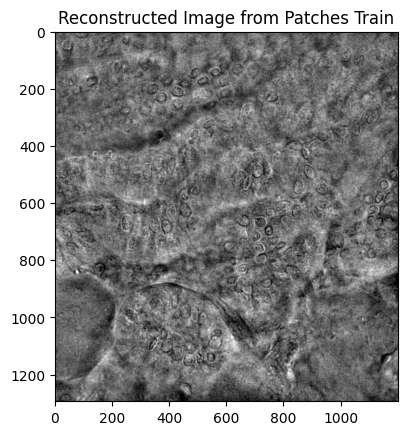

Processing stack 2 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 3 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 4 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing st

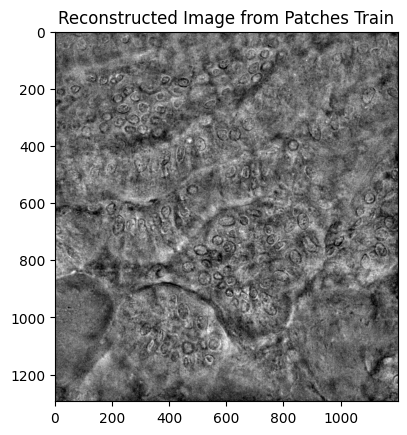

Processing stack 12 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 13 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 14 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

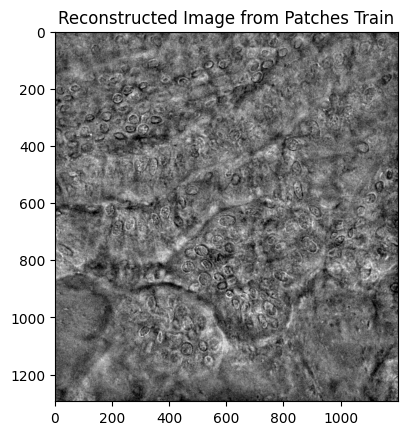

Processing stack 22 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 23 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 24 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

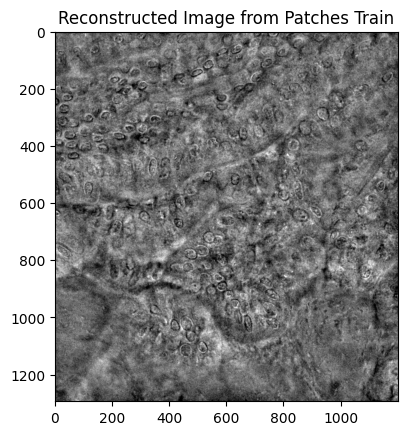

Processing stack 32 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 33 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 34 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

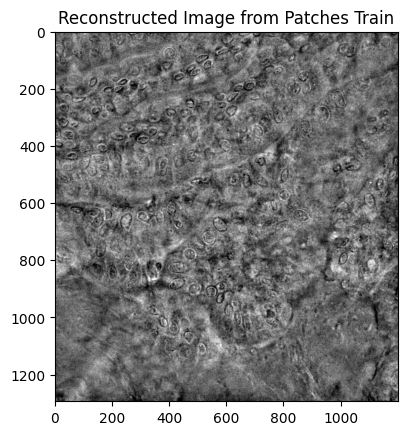

Processing stack 42 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 43 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 44 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

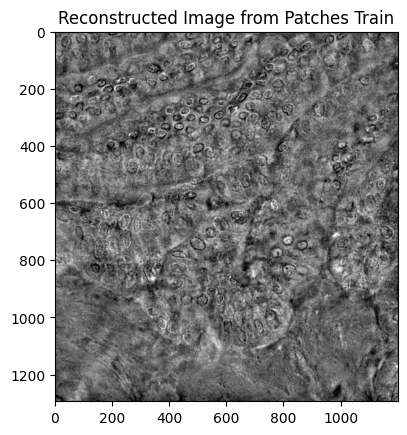

Processing stack 52 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 53 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 54 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

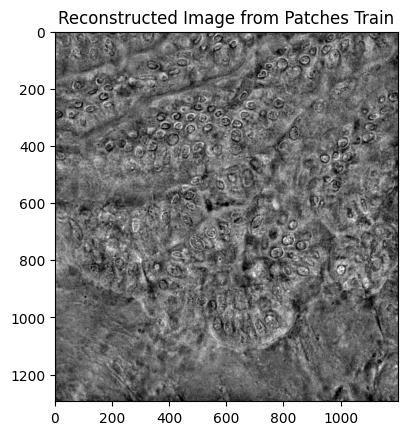

Processing stack 62 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 63 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 64 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

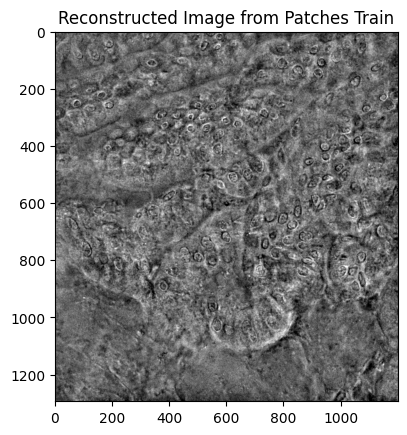

Processing stack 72 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 73 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 74 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

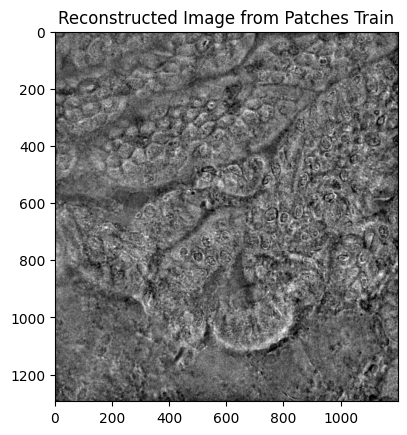

Processing stack 82 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 83 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 84 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

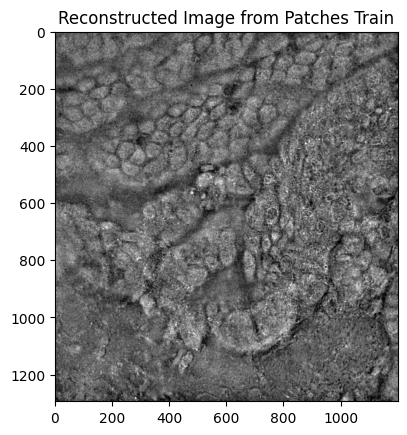

Processing stack 92 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 93 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 94 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_BIT_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing

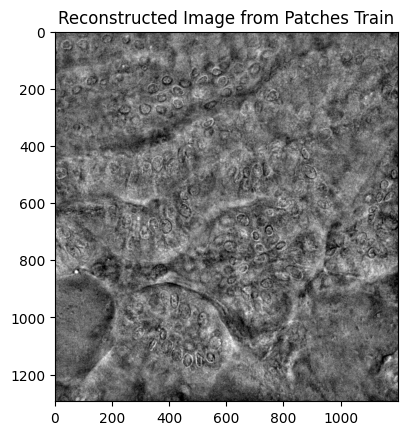

Processing stack 102 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 103 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 104 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

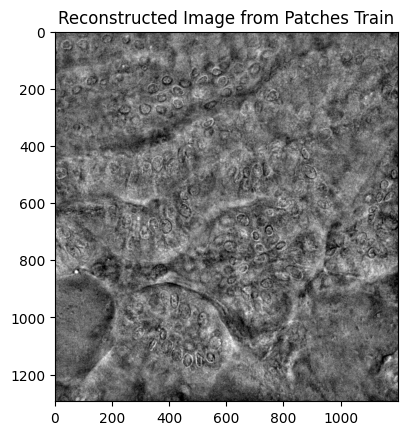

Processing stack 112 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 113 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 114 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

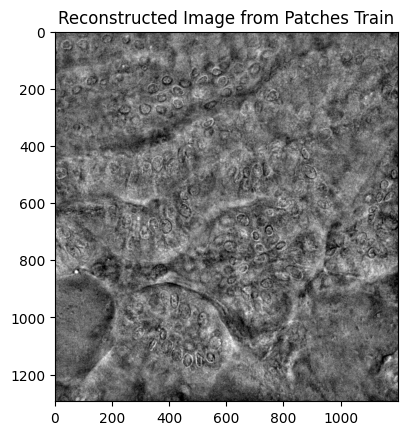

Processing stack 122 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 123 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 124 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

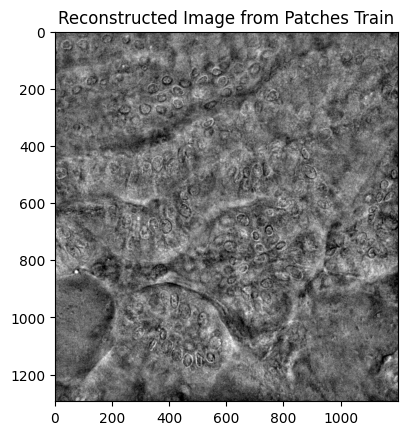

Processing stack 132 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 133 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 134 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

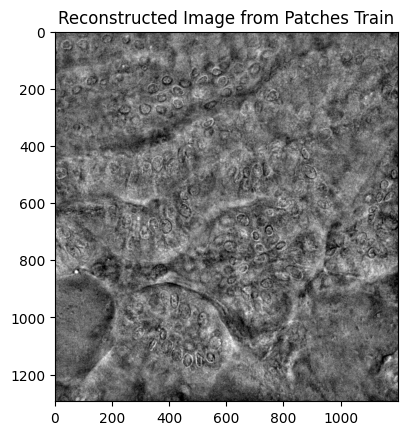

Processing stack 142 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 143 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 144 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

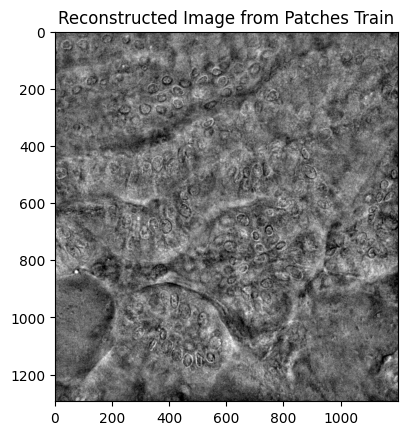

Processing stack 152 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 153 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 154 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

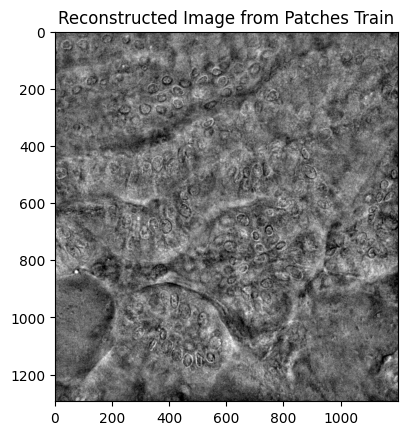

Processing stack 162 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 163 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 164 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

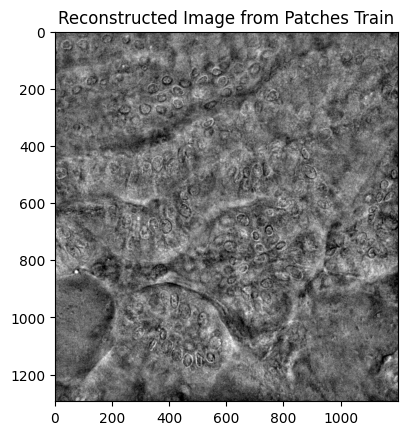

Processing stack 172 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 173 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 174 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

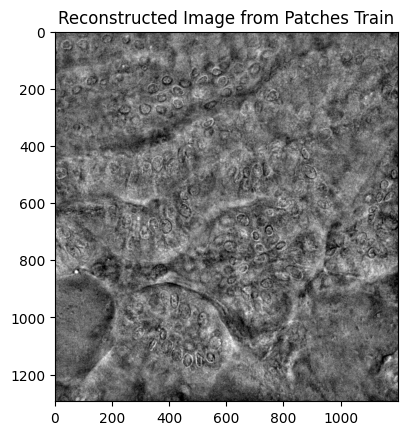

Processing stack 182 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 183 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 184 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

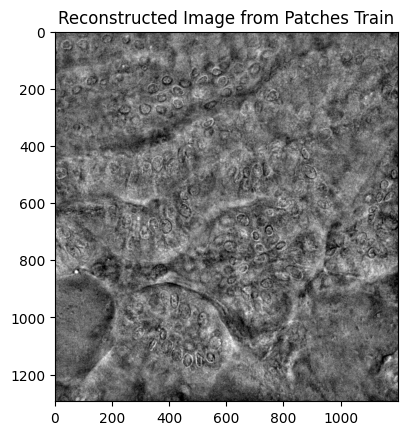

Processing stack 192 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 193 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch_metadata.txt
Processing stack 194 of 200
Original stack shape: (1294, 1200), dtype: uint8
Optimal Stride: 391x344
Saved 9 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts\roi_4\BIT\preprocessed_new\patches\crop_4_MUSE_green_crypt_3_X=0_Y=0_patches_stitch

In [21]:
# Train
root_data = r"C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\20260203_cropped_duodenum_crypts"

roi_folders = glob.glob(os.path.join(root_data, "roi_*"))
print(f"Found {len(roi_folders)} ROI folders for processing.")
training_folder = os.path.join(root_data, "trainA")
testing_folder = os.path.join(root_data, "testA")
os.makedirs(training_folder, exist_ok=True)
os.makedirs(testing_folder, exist_ok=True)

for i in range(3,4):#%len(roi_folders)):
    print(f"Processing sample duo_{i}")
    train_crop_root = os.path.join(root_data, roi_folders[i],'BIT', 'preprocessed_new')


    #input_path_train = r"C:\Users\durrlab-asong\OneDrive - Johns Hopkins\MUSE-BIT\20250721_duodenum_JH09118690\MUSE-BIT\duo_5_submucosa\in_focus\cropped_tifs\preprocessed"


    output_path_train = os.path.join(train_crop_root, 'patches')
    process_training_data(output_path_train, train_crop_root, 512, 512)


    # Invert the Patches. 
    inverted_path = os.path.join(train_crop_root, 'patches_inverted')
    invert_images_to_new_folder(output_path_train, inverted_path)

    # Combine into RGB for Training. 
    output_combined_rgb_path = os.path.join(train_crop_root, 'combined_rgb')
    combine_trios_to_rgb(output_path_train, inverted_path, output_path_train, output_combined_rgb_path)

    # Move .txt recon file to trainA folder and inverted folder
    copy_txt_files(output_path_train, inverted_path)
    copy_txt_files(output_path_train, output_combined_rgb_path)

    # Move to training folder
    print(output_path_train)
    if i % 2 == 0:  # Example condition to separate training and testing
        print("Moving to testing folder")
        move_muse_bit_bit_files(output_combined_rgb_path, testing_folder)
        copy_txt_files(output_path_train, testing_folder)
    else: 
        print("Moving to training folder")
        move_muse_bit_bit_files(output_combined_rgb_path, training_folder)
        copy_txt_files(output_path_train, training_folder)

